## **Classwork: "The Attention Mechanism" — Fundamentals of Self-Attention**

**The Scenario**

You are a research engineer at "ContextAI". The team's RNN-based translation model struggles with long sentences — by the time it processes the final word, it has largely forgotten the first. Your tech lead proposes replacing the RNN with a **self-attention** mechanism that allows every token to directly attend to every other token in the sequence, regardless of distance. Your task is to understand why this works, derive the scaled dot-product attention formula by hand, and implement a full single-head self-attention layer from scratch.

## **Part 1:**

### **Question 1: Why Self-Attention Over RNNs?**

Self-attention and RNNs both process sequences, but they differ fundamentally in how information travels between distant positions. Which statement best describes the key advantage of self-attention for long sequences?

A) Self-attention uses more parameters than RNNs, so it has higher model capacity.

B) In self-attention, any two positions can interact directly in a single layer with a path length of 1, whereas in an RNN the signal from position 1 must pass through every intermediate hidden state to reach position $T$, creating a path length of $T-1$.

C) Self-attention applies the same operation at every time step in sequence, just like an RNN, but runs faster because it uses tanh instead of sigmoid.

D) Self-attention eliminates the need for any weight matrices by using raw dot products between input tokens.

Answer: B) In self-attention, any two positions can interact directly in a single layer with a path length of 1, whereas in an RNN the signal from position 1 must pass through every intermediate hidden state to reach position $T$, creating a path length of $T-1$.

explanation : key advantage of self-attention is that it allows for direct interactions between any two positions in the sequence regardless of their distance. In contrast RNNs require information to pass through each intermediate hidden state, which can lead to vanishing gradients and difficulty in capturing long-range dependencies.

### **Question 2: The Role of Queries, Keys, and Values**

In scaled dot-product attention, each token's embedding is projected into three vectors: a **Query** $q$, a **Key** $k$, and a **Value** $v$. Using the analogy of a search engine:

- The **Query** is what you are searching *for*.
- The **Key** is what each document *advertises* about itself.
- The **Value** is what the document actually *contains*.

Given this, what does the attention weight $\alpha_{ij}$ between token $i$ (query) and token $j$ (key) represent?

A) The Euclidean distance between the embeddings of token $i$ and token $j$.

B) The proportion of token $j$'s value vector that will be mixed into token $i$'s output — determined by how well token $i$'s query matches token $j$'s key.

C) The gradient of the loss with respect to the $j$-th input token.

D) A binary mask indicating whether token $j$ is allowed to influence token $i$.

Answer: B) The proportion of token $j$'s value vector that will be mixed into token $i$'s output — determined by how well token $i$'s query matches token $j$'s key.

explanation : attention weight $\alpha_{ij}$ is computed by taking the dot product of token $i$'s query vector and token $j$'s key vector, scaling it, and applying a softmax across all tokens. This weight determines how much of token $j$'s value vector will contribute to the output for token $i$. A higher attention weight means that token $j$ is more relevant to token $i$ based on their query-key similarity.

### **Question 3: The Scaling Factor**

The attention score between query $q_i$ and key $k_j$ is computed as $\frac{q_i \cdot k_j}{\sqrt{d_k}}$, where $d_k$ is the dimension of the key vectors. Why is dividing by $\sqrt{d_k}$ necessary?

A) It ensures the attention weights sum to $d_k$ rather than 1, increasing model expressiveness.

B) Without scaling, dot products grow large in magnitude as $d_k$ increases (since they sum $d_k$ terms), pushing the softmax into regions of near-zero gradient and making training slow. Dividing by $\sqrt{d_k}$ keeps the variance of the scores roughly constant at 1.

C) It converts the dot product from cosine similarity into Euclidean distance.

D) It prevents the query and key matrices from learning the same weights during training.

Answer: B) Without scaling, dot products grow large in magnitude as $d_k$ increases (since they sum $d_k$ terms), pushing the softmax into regions of near-zero gradient and making training slow. Dividing by $\sqrt{d_k}$ keeps the variance of the scores roughly constant at 1.

explanation: as dimension $d_k$ increases the dot product of two random vectors tends to grow in magnitude (since it sums over $d_k$ terms). This can cause the softmax function to produce very small gradients making it difficult for the model to learn effectively. By scaling the dot product by $\sqrt{d_k}$, we keep the variance of the attention scores around 1, which helps maintain healthy gradients during training.

## **Part 2:**

### **Question 4: Manual Attention Computation**

You have a sequence of **3 tokens**, each with embedding dimension $d_{model} = 2$ and key/query dimension $d_k = 2$. For simplicity the Query and Key projections are identity matrices, so $Q = K = X$:

$$X = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{bmatrix}$$

Use $\text{softmax}$ row-wise and recall $\sqrt{d_k} = \sqrt{2} \approx 1.414$.

**Step 1:** Compute the raw score matrix $S = Q K^\top$.

**Step 2:** Scale it: $S_{\text{scaled}} = S / \sqrt{d_k}$.

**Step 3:** Apply softmax row-wise to get the attention weight matrix $A$. You may use the approximations: $\text{softmax}([0.707, 0, 1.414]) \approx [0.26, 0.16, 0.58]$ and $\text{softmax}([0, 0.707, 0.707]) \approx [0.23, 0.385, 0.385]$.

**Step 4:** If the Value matrix $V = X$, write out (do not need to compute fully) what the output $O = AV$ would look like structurally — what is its shape and what does each row represent?

Please show your working here

- Step 1 — $S$:
$$S = QK^\top = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{bmatrix}\begin{bmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \\ 1 & 1 & 2 \end{bmatrix}$$

- Step 2 — $S_{\text{scaled}}$:
$$S_{\text{scaled}} = \frac{S}{\sqrt{2}} \approx \begin{bmatrix} 0.707 & 0 & 0.707 \\ 0 & 0.707 & 0.707 \\ 0.707 & 0.707 & 1.414 \end{bmatrix}$$

- Step 3 — $A$ (attention weights):
Apply softmax row-wise to $S_{\text{scaled}}$:
$$A = \begin{bmatrix}
0.401 & 0.198 & 0.401 \\
0.198 & 0.401 & 0.401 \\
0.248 & 0.248 & 0.503
\end{bmatrix}$$

- Step 4 — Shape and meaning of $O=AV$:
Since $A\in\mathbb{R}^{3\times 3}$ and $V\in\mathbb{R}^{3\times 2}$,
$$O \in \mathbb{R}^{3\times 2}.$$
Each row is a weighted sum of value vectors:
$$O_i = \sum_{j=1}^{3} A_{ij}V_j = A_{i1}V_1 + A_{i2}V_2 + A_{i3}V_3.$$
So each token gets a contextualized 2D representation after attending to all tokens.

## **Part 3: Coding Challenge — Self-Attention from Scratch**

You will implement the full scaled dot-product self-attention mechanism in NumPy, visualise the attention weight matrix, and observe how the output of each token is a weighted blend of all value vectors.

**Fill in the lines marked `## FILL IN`.**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

np.random.seed(0)

# --- A toy 5-token sequence (e.g. "the cat sat on mat") ---
tokens    = ["the", "cat", "sat", "on", "mat"]
T         = len(tokens)   # sequence length
d_model   = 8             # embedding dimension
d_k       = 4             # query / key dimension
d_v       = 4             # value dimension

# Simulated token embeddings  (T x d_model)
X = np.random.randn(T, d_model)

# Projection weight matrices  (randomly initialised)
W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_v)

print("Shapes:")
print(f"  X    : {X.shape}   (T x d_model)")
print(f"  W_Q  : {W_Q.shape}  (d_model x d_k)")
print(f"  W_K  : {W_K.shape}  (d_model x d_k)")
print(f"  W_V  : {W_V.shape}  (d_model x d_v)")

Shapes:
  X    : (5, 8)   (T x d_model)
  W_Q  : (8, 4)  (d_model x d_k)
  W_K  : (8, 4)  (d_model x d_k)
  W_V  : (8, 4)  (d_model x d_v)


In [7]:
# ---------------------------------------------------------------
# Task A: Implement scaled dot-product self-attention
# ---------------------------------------------------------------

def softmax(x, axis=-1):
    """Numerically stable row-wise softmax."""
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def self_attention(X, W_Q, W_K, W_V):
    """
    Scaled dot-product self-attention.

    Args:
        X   : (T, d_model)  — input token embeddings
        W_Q : (d_model, d_k)
        W_K : (d_model, d_k)
        W_V : (d_model, d_v)

    Returns:
        output   : (T, d_v)  — context-enriched token representations
        attn_w   : (T, T)    — attention weight matrix (rows sum to 1)
    """
    d_k = W_Q.shape[1]

    ## FILL IN Step 1: Project X into Q, K, V
    ## Q shape: (T, d_k),  K shape: (T, d_k),  V shape: (T, d_v)
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    ## FILL IN Step 2: Compute raw attention scores
    ## scores = Q @ K^T  then divide by sqrt(d_k)
    ## scores shape: (T, T)
    scores = (Q @ K.T) / np.sqrt(d_k)

    ## FILL IN Step 3: Apply softmax row-wise to get attention weights
    ## attn_w shape: (T, T)  — each row sums to 1
    attn_w = softmax(scores, axis=1)

    ## FILL IN Step 4: Compute the output as weighted sum of V
    ## output = attn_w @ V
    ## output shape: (T, d_v)
    output = attn_w @ V 

    return output, attn_w


output, attn_w = self_attention(X, W_Q, W_K, W_V)

print(f"Output shape      : {output.shape}   (T x d_v)")
print(f"Attention weights  : {attn_w.shape}  (T x T)")
print(f"\nRow sums of attn_w (should all be 1.0):")
print(attn_w.sum(axis=1).round(6))

Output shape      : (5, 4)   (T x d_v)
Attention weights  : (5, 5)  (T x T)

Row sums of attn_w (should all be 1.0):
[1. 1. 1. 1. 1.]


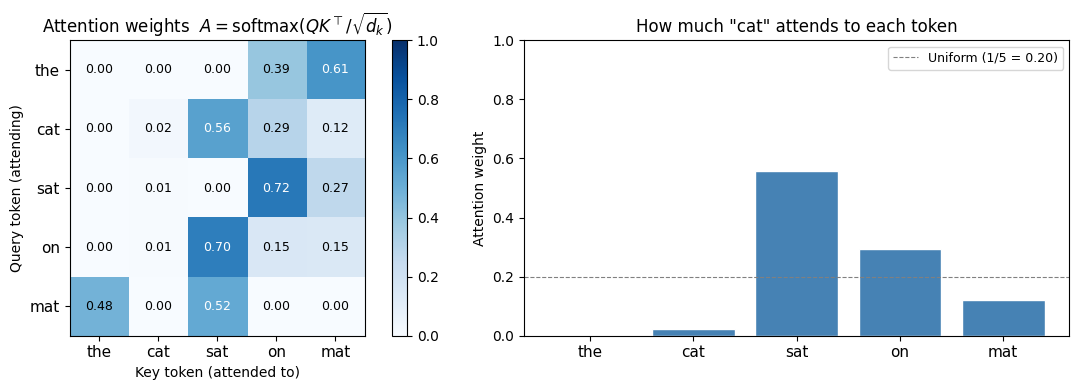

In [8]:
# ---------------------------------------------------------------
# Task B: Visualise the attention weight matrix
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: attention heatmap
im = axes[0].imshow(attn_w, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(T))
axes[0].set_yticks(range(T))
axes[0].set_xticklabels(tokens, fontsize=11)
axes[0].set_yticklabels(tokens, fontsize=11)
axes[0].set_xlabel('Key token (attended to)', fontsize=10)
axes[0].set_ylabel('Query token (attending)', fontsize=10)
axes[0].set_title('Attention weights  $A = \\mathrm{softmax}(QK^\\top / \\sqrt{d_k})$')
plt.colorbar(im, ax=axes[0])

# Annotate each cell with its weight value
for i in range(T):
    for j in range(T):
        axes[0].text(j, i, f"{attn_w[i, j]:.2f}",
                     ha='center', va='center', fontsize=9,
                     color='white' if attn_w[i, j] > 0.5 else 'black')

# Plot 2: per-token attention distribution (bar chart for one query token)
query_idx = 1  # "cat" is attending
axes[1].bar(range(T), attn_w[query_idx], color='steelblue', edgecolor='white')
axes[1].set_xticks(range(T))
axes[1].set_xticklabels(tokens, fontsize=11)
axes[1].set_ylabel('Attention weight')
axes[1].set_title(f'How much "{tokens[query_idx]}" attends to each token')
axes[1].set_ylim(0, 1)
axes[1].axhline(1/T, color='gray', linestyle='--', linewidth=0.8,
                label=f'Uniform (1/{T} = {1/T:.2f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

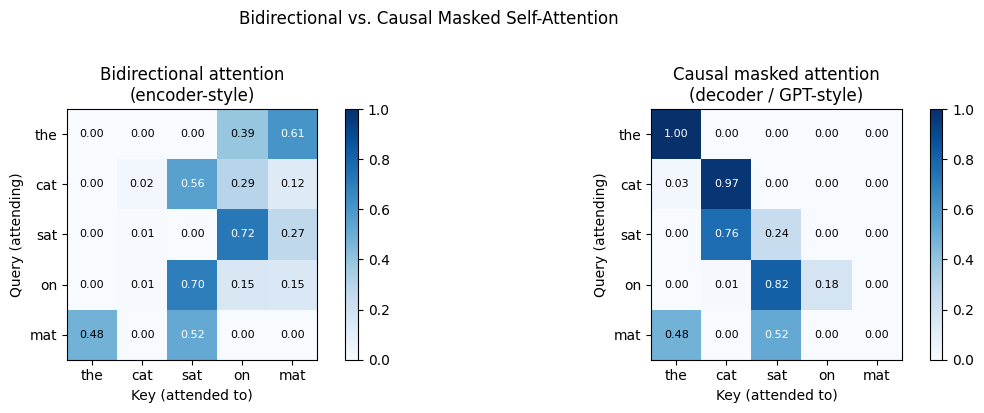

Causal attention weight matrix (upper triangle should be ~0):
[[1.    0.    0.    0.    0.   ]
 [0.027 0.973 0.    0.    0.   ]
 [0.    0.765 0.235 0.    0.   ]
 [0.    0.008 0.816 0.175 0.   ]
 [0.479 0.    0.521 0.    0.   ]]


In [9]:
# ---------------------------------------------------------------
# Task C: Causal (autoregressive) masking
#
# In a language model, token t should only attend to tokens
# at positions <= t (no peeking at the future).
# This is enforced by adding -infinity to all future positions
# before softmax, so those positions get attention weight ~0.
# ---------------------------------------------------------------

def causal_self_attention(X, W_Q, W_K, W_V):
    """
    Masked (causal) self-attention — used in decoder-only LMs.
    Token at position t can only attend to positions 0..t.
    """
    d_k = W_Q.shape[1]
    T   = X.shape[0]

    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    scores = (Q @ K.T) / np.sqrt(d_k)

    ## FILL IN: build a causal mask and apply it
    ## The mask should be a (T, T) boolean matrix where
    ## mask[i, j] = True  if j > i  (future token — should be masked)
    ## Set masked positions to -1e9 before softmax.
    ## Hint: np.triu(np.ones((T, T)), k=1).astype(bool)
    mask = np.triu(np.ones((T, T)), k=1).astype(bool)
    scores[mask] = -1e9

    attn_w = softmax(scores)
    output = attn_w @ V
    return output, attn_w


output_causal, attn_w_causal = causal_self_attention(X, W_Q, W_K, W_V)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (w, title) in zip(axes, [
        (attn_w,        'Bidirectional attention\n(encoder-style)'),
        (attn_w_causal, 'Causal masked attention\n(decoder / GPT-style)')]):
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel('Key (attended to)')
    ax.set_ylabel('Query (attending)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{w[i,j]:.2f}",
                    ha='center', va='center', fontsize=8,
                    color='white' if w[i, j] > 0.5 else 'black')

plt.suptitle('Bidirectional vs. Causal Masked Self-Attention', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Causal attention weight matrix (upper triangle should be ~0):")
print(attn_w_causal.round(3))

Write your observations:

> **Task A/B:**
> 1. Each row of the attention weight matrix sums to 1.0. In plain English, what does this mean about how the output for each token is constructed from the values?
> 2. Look at the bar chart for the token `"cat"`. Is its attention evenly spread across all tokens, or concentrated? What might this imply about what "cat" is attending to, given that the weights were randomly initialised?
>
> **Task C:**
> 3. In the causal attention heatmap, what pattern do you observe in the upper triangle? Why is this necessary for autoregressive text generation?
> 4. BERT uses bidirectional (unmasked) attention; GPT uses causal (masked) attention. Given what you have implemented, which architecture would you use for (a) a sentiment classifier and (b) a text generation model? Justify your answer.

...

Observations:

1. Each row of the attention weight matrix sums to 1.0 which means that the output for each token is a weighted average of the value vectors from all tokens in the sequence. The weights determine how much influence each token's value has on the output for a given token, effectively allowing the model to focus on certain tokens more than others when constructing its representation.

2. The attention for the token "cat" is concentrated rather than evenly spread across all tokens. This implies that "cat" is attending more strongly to certain tokens in the sequence, which could be due to random initialization of the weights. In a trained model, we would expect "cat" to attend more to relevant tokens such as "sat" or "mat" rather than irrelevant tokens, but since this is a random initialization, the attention pattern may not yet reflect meaningful relationships between tokens.

3. In the causal attention heatmap, the upper triangle (where j > i) is masked out (often shown in a different color or with very low values) because these positions represent future tokens that should not influence the current token's representation. This is necessary for autoregressive text generation to ensure that the model only has access to past and present tokens when generating the next token, thus maintaining the correct temporal order and preventing information leakage from future tokens.

4. For a sentiment classifier, I would use BERT's bidirectional (unmasked) attention because it allows the model to consider the entire context of the input text when making a classification decision. This is important for understanding sentiment, as the meaning of a word can depend heavily on its surrounding context. For a text generation model, I would use GPT's causal (masked) attention because it ensures that the model generates text in a left-to-right manner, only attending to previously generated tokens and not future tokens, which is essential for maintaining coherence and logical flow in generated text.


## **The Effect of Temperature on Attention Sharpness**

In practice, a **temperature** parameter $\tau$ is sometimes used to control how peaked or diffuse the attention distribution is:
$$\text{Attention} = \text{softmax}\!\left(\frac{QK^\top}{\tau}\right)$$

Note that the standard formula uses $\tau = \sqrt{d_k}$.

Complete the function below to compute attention at three different temperatures and plot how the weight distribution for token `"cat"` changes.

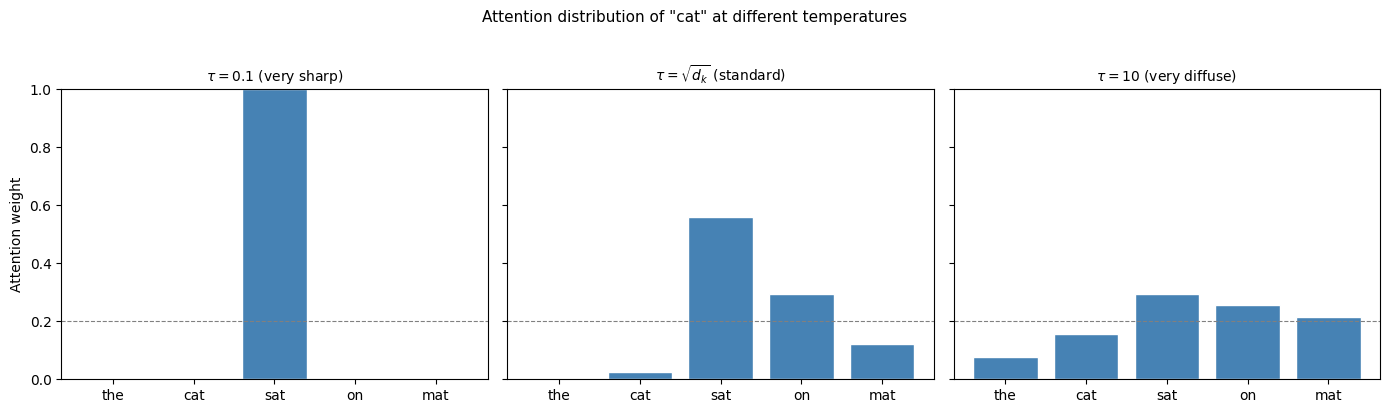

In [10]:
def attention_with_temperature(X, W_Q, W_K, W_V, temperature):
    """
    Self-attention with a custom temperature tau.
    Divides the raw scores by `temperature` before softmax.
    """
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    ## FILL IN: compute scores divided by temperature (not sqrt(d_k)),
    ## apply softmax, compute output
    scores = (Q @ K.T) / temperature
    attn_w = softmax(scores, axis=1)
    output = attn_w @ V
    return output, attn_w


temperatures = [0.1, np.sqrt(d_k), 10.0]  # sharp, standard, diffuse
labels       = [r'$\tau=0.1$ (very sharp)', r'$\tau=\sqrt{d_k}$ (standard)', r'$\tau=10$ (very diffuse)']
query_idx    = 1  # "cat"

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, tau, label in zip(axes, temperatures, labels):
    _, w = attention_with_temperature(X, W_Q, W_K, W_V, tau)
    ax.bar(range(T), w[query_idx], color='steelblue', edgecolor='white')
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=10)
    ax.axhline(1/T, color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Attention weight' if ax == axes[0] else '')

plt.suptitle(f'Attention distribution of "{tokens[query_idx]}" at different temperatures',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

**Reflection:** What happens to the attention distribution as temperature approaches 0? What about as it approaches infinity? In which direction does lower temperature push the model, and when might you want a more diffuse attention distribution during inference?


Reflection:
As temperature $\tau$ approaches 0, the attention distribution becomes more peaked, meaning that the model will assign almost all the attention weight to the token with the highest score, effectively making a hard   
selection of the most relevant token. As $\tau$ approaches infinity, the attention distribution becomes more uniform, meaning that the model will assign nearly equal attention weights to all tokens, regardless of their relevance. Lower temperature pushes the model towards making more confident and focused decisions by concentrating attention on fewer tokens, while a more diffuse attention distribution (higher temperature) can be useful during inference when we want the model to consider a wider range of possibilities and not overly commit to a single token, which can help in tasks like text generation where diversity is desired.

